In [1]:
import matplotlib
from matplotlib import pyplot as plt
from pylab import *
import ase
from ase.visualize import view
from ase.lattice import HEX2D
import numpy as np

import sisl 
import sisl.viz
    
from tqdm import tqdm   
from SE_utils import *
from PDOs_utils import *

In [2]:
HOME_DIR='./'

# Graphene Band Structure

In [3]:
bond=1.43
C = sisl.Atom(6, R = bond + 0.01)
# Create graphene unit-cell
gr = sisl.geom.graphene(bond, C)

# Create the tight-binding Hamiltonian
Ham0 = sisl.Hamiltonian(gr)
R = [0.1 * bond, bond + 0.01]

for ia in gr:
    idx_a = gr.close(ia, R)
    # On-site
    Ham0[ia, idx_a[0]] = 0.
    # Nearest neighbour hopping
    Ham0[ia, idx_a[1]] = -2.7

In [32]:
import os
from ase import Atoms
from ase.calculators.siesta import Siesta
from ase.units import Ry

# 1. Create the ASE object from raw geometry
gr_ase = Atoms(symbols='C2', positions=gr.xyz, cell=gr.lattice.cell, pbc=True)

# 2. Setup the Calculator
pp_path = os.path.abspath("./Graphene")
calc = Siesta(
    label="Graphene/siesta",
    pseudo_path=pp_path,
    xc="PBE",
    mesh_cutoff=200 * Ry,
    basis_set="SZ",
    kpts=(10, 10, 1),
    fdf_arguments={
        "TS.HS.Save": True,
        "WriteHamiltonian": True,
    }
)

# 3. Write the initial file
gr_ase.calc = calc
calc.write_input(gr_ase, properties=[])

# 4. CLEANING STEP: Strip out ".1" and ".psml" from the generated FDF
fdf_path = "Graphene/siesta.fdf"
with open(fdf_path, "r") as f:
    content = f.read()

# Replace the problematic strings
content = content.replace("C.1", "C").replace("C.psml", "").replace("C.1.psml", "")

with open(fdf_path, "w") as f:
    f.write(content)

print("Task 1 Complete: FDF generated and cleaned of '.1' suffixes.")
!grep -A 3 "ChemicalSpecieslabel" Graphene/siesta.fdf

Task 1 Complete: FDF generated and cleaned of '.1' suffixes.
%block ChemicalSpecieslabel
    1 6 C 
%endblock ChemicalSpecieslabel

%block PAO.BasisSizes
    C	SZ


In [5]:
!ls Graphene/ -ltr

total 888
-rwxr-xr-x 1 bastian bastian  68666 Feb  9 15:06 C.psml
-rw-r--r-- 1 bastian bastian    885 Feb  9 15:06 INPUT_TMP.37735
-rw-r--r-- 1 bastian bastian  15052 Feb  9 15:06 siesta.DM
-rw-r--r-- 1 bastian bastian  28756 Feb  9 15:06 fdf.20260209T150642.644.log
-rw-r--r-- 1 bastian bastian    885 Feb  9 15:37 INPUT_TMP.30675
-rw-r--r-- 1 bastian bastian  28492 Feb  9 15:37 fdf.20260209T153747.988.log
-rw-r--r-- 1 bastian bastian    885 Feb 10 13:58 INPUT_TMP.88500
-rw-r--r-- 1 bastian bastian 241603 Feb 10 13:58 C.ion
-rw-r--r-- 1 bastian bastian  41620 Feb 10 13:58 C.ion.nc
-rw-r--r-- 1 bastian bastian 229420 Feb 10 13:58 C.ion.xml
-rw-r--r-- 1 bastian bastian   1950 Feb 10 13:58 siesta.BONDS
-rw-r--r-- 1 bastian bastian   3933 Feb 10 13:58 siesta.KP
-rw-r--r-- 1 bastian bastian    208 Feb 10 13:58 PARALLEL_DIST
-rw-r--r-- 1 bastian bastian   3487 Feb 10 13:58 NON_TRIMMED_KP_LIST
-rw-r--r-- 1 bastian bastian    600 Feb 10 13:58 siesta.XV
-rw-r--r-- 1 bastian bastian  31390 Feb 10

# edit the `siesta.fdf`

change all entries of `C.1` to `C`

In [6]:
!cd Graphene/ && mpirun -np 4 siesta < siesta.fdf > siesta.out
!echo '########### siesta.out ###########'
!tail -n 20 Graphene/siesta.out

--------------------------------------------------------------------------
mpirun was unable to find the specified executable file, and therefore
did not launch the job.  This error was first reported for process
rank 0; it may have occurred for other processes as well.

NOTE: A common cause for this error is misspelling a mpirun command
      line parameter option (remember that mpirun interprets the first
      unrecognized command line token as the executable).

Node:       Yoga7i-Bastian
Executable: siesta
--------------------------------------------------------------------------
########### siesta.out ###########
4 total processes failed to start


In [7]:
H0_DFT=sisl.get_sile(HOME_DIR+'Graphene/siesta.fdf').read_hamiltonian()

In [8]:
band_pz = sisl.BandStructure(Ham0, points=[ # [-1/3, -2/3, 0], 
                                           [0., 0., 0.], [1 / 3, 2 / 3, 0], [0, 0.5, 0],[0., 0., 0.]],divisions= 300, names=[ # r"$K'$", 
                                                                                                                             r'$\Gamma$', r"$K$", r"$M$",r'$\Gamma$'])
band = sisl.BandStructure(H0_DFT,points= [ # [-1/3, -2/3, 0], 
                                          [0., 0., 0.], [1 / 3, 2 / 3, 0], [0, 0.5, 0],[0., 0., 0.]],divisions= 300, names=[ # r"$K'$", 
                                                                                                                            r'$\Gamma$', r"$K$", r"$M$",r'$\Gamma$'])

(0.0, 4.001394287550308)

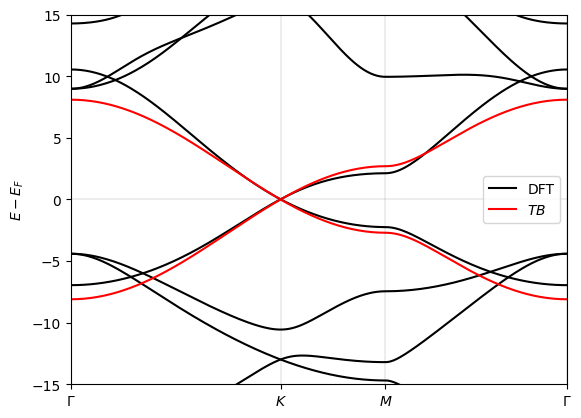

In [9]:
fig = plt.figure('Bands')
ax = fig.add_subplot(111)
       
lk, kt, kl = band.lineark(True)
ax.set_ylabel(r'$E-E_F$')
bs = []
for ik, eigh in enumerate(band.apply.eigh()):
    bs.append(eigh)

bs = np.array(bs)
ax.set_ylim(-15,15)
firsttime=True
    
for bk in bs.T:
    if(firsttime):
        ax.plot(lk, bk, c='k', label='DFT')
        firsttime=False
    else:
        ax.plot(lk, bk, c='k')

bs = []
for ik, eigh in enumerate(band_pz.apply.eigh()):
    bs.append(eigh)
bs= np.array(bs)

firsttime=True
    
for bk in bs.T:
    if(firsttime):
        ax.plot(lk, bk, c='r', label=r'$TB$')
        firsttime=False
    else:
        ax.plot(lk, bk, c='r')
ax.hlines(y=0,xmin=0,xmax=10,color='k',lw=0.1)
                
xcoords = kt
for k in xcoords:
    plt.axvline(x=k,c='k',lw=0.1)        
plt.xticks(kt, kl)        
ax.legend(loc='center right')
ax.set_xlim(kt[0],kt[-1])


# Generate Files for TBT

In [31]:
Ham=Ham0.tile(1,0).tile(1,1)
print(Ham0.nsc)
print(Ham.nsc)

[3 3 1]
[3 3 1]


In [11]:
# Number of repetitions in a,b 
N0 = 12
N1 = 12
nk1 = int(np.ceil(1000/N1))
eta = 0.001* 1j
rse = sisl.RealSpaceSE(Ham, 0, 1, (N0, N1, 1)) 
rse.setup(eta= 0.001, bz=sisl.MonkhorstPack(Ham, [1, nk1, 1]))

In [12]:
# Electrode
from pathlib import Path
H_elec, elec_indices=rse.real_space_coupling(ret_indices=True)
Path("TBT").mkdir(parents=False, exist_ok=True)
H_elec.write(HOME_DIR+'TBT/Elec.nc')

In [13]:
# Device Hamiltonian
# equivakent to H = rse.real_space_parent()
HamNN=Ham.tile(N0,0).tile(N1,1)
HamNN.set_nsc([1,1,1])
geomNN = HamNN.geometry

# Get indices inside atoms and elec atoms
all_atoms=np.arange(0,HamNN.na)
inside_atoms = np.delete(all_atoms, elec_indices)
Haminside=HamNN.sub(inside_atoms)
HamSE=HamNN.sub(elec_indices)

# reorder indixes
alist = np.concatenate([elec_indices, inside_atoms])
HamNN_reorder=HamNN.sub(alist)
HamNN_reorder.set_nsc([1,1,1])
HamNN_reorder.write(HOME_DIR+'TBT/Device.nc')

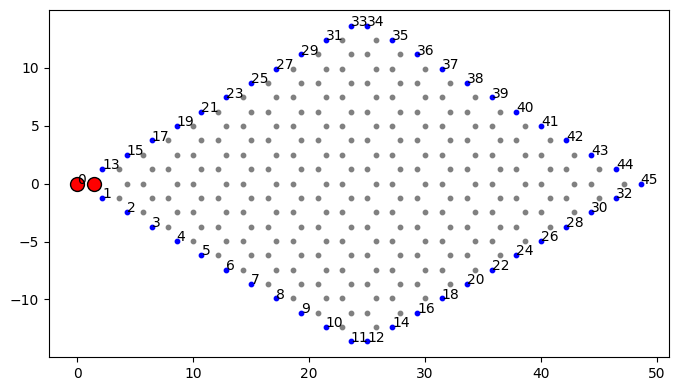

In [14]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')
for i in np.arange(0,HamNN_reorder.na):
    if i < HamSE.na:
        ax.text(HamNN_reorder.xyz[i,0],HamNN_reorder.xyz[i,1],i,c='k')
        plt.scatter(HamNN_reorder.xyz[i,0],HamNN_reorder.geometry.xyz[i,1],c='b',s=10,label='Elec')
    else:
        plt.scatter(HamNN_reorder.xyz[i,0],HamNN_reorder.geometry.xyz[i,1],c='gray',s=10,label='Dev')
for idx in np.arange(Ham.geometry.na):
    ax.scatter(Ham.geometry.xyz[idx,0],Ham.geometry.xyz[idx,1],c='red',s=100,edgecolors='k',linewidths=1)

In [15]:
dE=0.01
Emin, Emax = -3.0, 3.0
E = np.arange(Emin, Emax + dE / 2, dE)
#sisl.io.tableSile(HOME_DIR+"TBT/contour.E", 'w').write_data(E, np.zeros(E.size) + dE)

In [16]:
bz = sisl.BrillouinZone(H_elec)

In [17]:
### Now write the GF file as input to TBT
eta = 0.001* 1j
t0 = time.perf_counter()

with sisl.io.tbtgfSileTBtrans(HOME_DIR+"TBT/graphene.TBTGF") as f:
   f.write_header(bz, E+ eta )
   for ispin, new_k, k, e in tqdm(f):
        if new_k:
            H = H_elec.Hk(format='array', dtype=np.complex128)
            S = H_elec.Sk(format='array', dtype=np.complex128)
            f.write_hamiltonian(H, S)
        RSE = rse.self_energy(e + eta,bulk=True, coupling=True)
        #RSE_reordered = RSE[np.ix_(alist, alist)]
        f.write_self_energy(RSE)
t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.2f} seconds")

100%|██████████| 601/601 [03:28<00:00,  2.88it/s]

Total runtime: 194.82 seconds


In [ ]:
f = open(HOME_DIR+"TBT/tbt.fdf", 'w')
f.write(
"""
SystemName        graphene
SystemLabel       graphene

# ---------- Hamiltonian ----------
TBT.HS Device.nc

#---------- Electrode ----------
%block TS.Elecs
    Elec
%endblock TS.Elecs

%block TS.Elec.Elec
    HS Elec.nc
    semi-inf-direction  abc 
    electrode-position 1
    Out-of-core true
    tbt.Gf      graphene.TBTGF
%endblock 

# ---------- k-point sampling ----------
TBT.k [1 1 1]

# ---------- Contour line ----------
%block TBT.Contour.line
  part line
     from -3 eV to 3 eV
       file contour.E 
%endblock TBT.Contour.line

# ---------- Output ----------
TBT.DOS.A
TBT.DOS.Gf
TBT.Current.Orb
"""
       )
f.close()

# Calculation in sisl

In [19]:
print(Ham.nsc)

[3 3 1]


In [20]:
# Energy contour
eta = 0.001* 1j
dE=0.1
Emin, Emax = -3.0, 3.0
energies = np.arange(Emin, Emax + dE / 2, dE)

# Real Space Self Energies
N0 = 12
N1 = 12
nk1 = int(np.ceil(3*900/N1))

rse = sisl.RealSpaceSE(Ham, 0, 1, (N0, N1, 1))
rse.setup(eta= 0.001, bz=sisl.MonkhorstPack(Ham, [1, nk1, 1]))
elec_indices = rse.real_space_coupling(geomNN)[1]
nC = len(elec_indices)   # number of coupling atoms

# Hamiltonian Self Energy
HamNN=Ham.tile(N0,0).tile(N1,1)
geomNN = HamNN.geometry
HamNN.set_nsc([1,1,1]) # remove al pbc
geomNN = HamNN.geometry

# indexes sort
all_atoms=np.arange(0,HamNN.na)
inside_atoms = np.delete(all_atoms, elec_indices, axis=0)
alist = np.concatenate([elec_indices, inside_atoms])

# Reordering Hamiltonain
HamNN_reorder=HamNN.sub(alist)
HamNN_reorder.reduce()
HamNN_reorder.set_nsc([1,1,1]) # remove al pbc
H_sub = HamNN_reorder.Hk(format="array")   
S_sub= HamNN_reorder.Sk(format="array")

In [21]:
t0 = time.perf_counter()
DOS, LDOS=loop_GF(energies,eta,rse,H_sub,S_sub,alist=alist)
t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print(f"Time per energy: {(t1 - t0)/len(energies):.4f} s")
LDOS_dev= LDOS[nC:,:]
DOS_dev = LDOS_dev.sum(axis=0)  

DOS: 100%|██████████| 61/61 [01:08<00:00,  1.12s/it]

Total runtime: 63.89 seconds
Time per energy: 1.0474 s


# Plotting

In [22]:
#tbt = sisl.get_sile('TBT/graphene.TBT.nc')

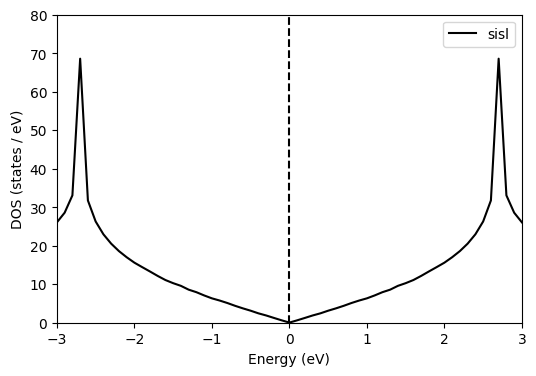

In [23]:
# === plot DOS ===
E_idx=30
plt.figure(figsize=(6,4))
#plt.plot(tbt.E, tbt.DOS(), lw=1.5,c='r',label='TBT')
plt.plot(energies,DOS_dev,c='k',label='sisl')
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states / eV)")
plt.vlines(x=energies[E_idx],ymin=0,ymax=600,color='k',linestyle='dashed')
plt.ylim(0,80)
plt.xlim(-3,3)
plt.legend()
plt.show()

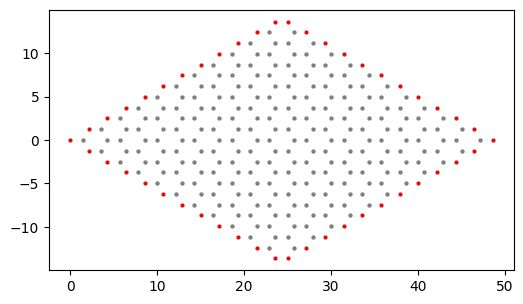

In [24]:
fig, ax = plt.subplots(figsize=(6,6))
E_idx=30
scale=50000
ax.set_aspect('equal')
for i in np.arange(0,HamNN_reorder.na):
    if i < HamSE.na:
        ax.scatter(HamNN_reorder.xyz[i,0],HamNN_reorder.geometry.xyz[i,1],c='r',s=scale*LDOS.T[E_idx][i],edgecolors='k',lw=0.1)
    else:
        ax.scatter(HamNN_reorder.xyz[i,0],HamNN_reorder.geometry.xyz[i,1],c='gray',edgecolors='k',s=scale*LDOS.T[E_idx][i],lw=0.1)

In [25]:
def calc_RSE(E,eta,rse,H_sub,S_sub,alist=None):
    z = E +  eta
    RSE = rse.self_energy(z)
    if alist is not None:
        RSE = RSE[np.ix_(alist, alist)]
    return RSE

4.432218481120742e-16 -2608.900407774883


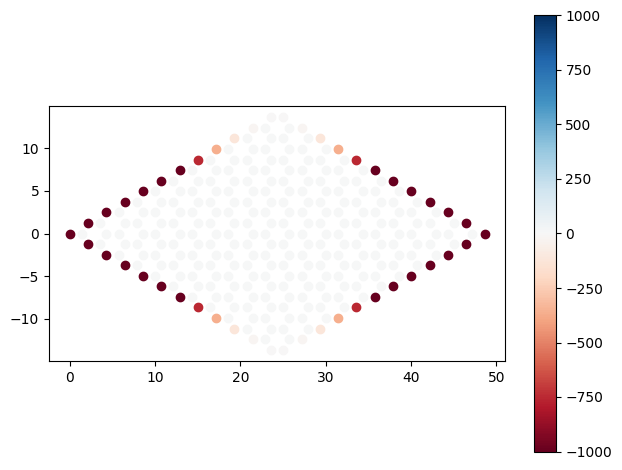

In [26]:
E = 0.0
component="imag"
SE_real=[]
SE_imag=[]
SE = calc_RSE(E, eta, rse, H_sub, S_sub, alist)
SE_real.append(np.real(SE))
SE_imag.append(np.imag(SE))
SE_real=np.array(SE_real)
SE_imag=np.array(SE_imag)

xyz = HamNN_reorder.geometry.xyz
x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
diag = np.real(SE.diagonal()) if component == "real" else np.imag(SE.diagonal())
print(max(diag),min(diag))

fig=plt.figure()
ax = fig.add_subplot()
ax.set_aspect('equal')

for i in np.arange(0,HamNN_reorder.na):
    sc=ax.scatter(x[i], y[i], c=diag[i],vmax=1000,vmin=-1000,cmap='RdBu')
plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

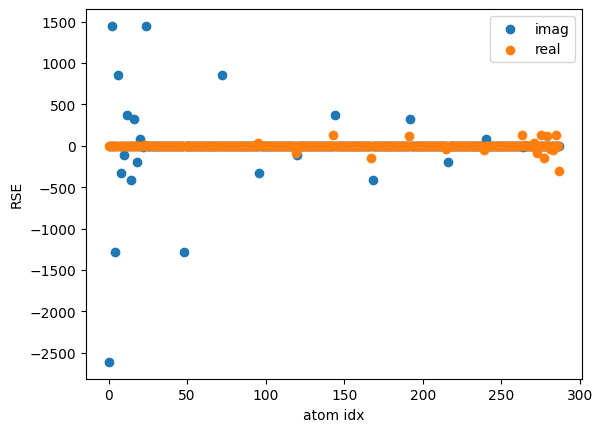

In [27]:
plt.scatter(alist,SE_imag.diagonal(),label='imag')
plt.scatter(alist,SE_real.diagonal(),label='real')
plt.xlabel('atom idx')
plt.ylabel('RSE')
plt.legend()

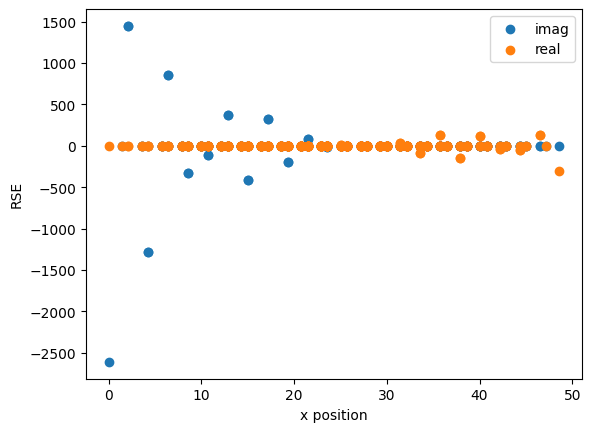

In [28]:
plt.scatter(HamNN_reorder.xyz[:,0],SE_imag.diagonal(),label='imag')
plt.scatter(HamNN_reorder.xyz[:,0],SE_real.diagonal(),label='real')
plt.xlabel('x position')
plt.ylabel('RSE')
plt.legend()

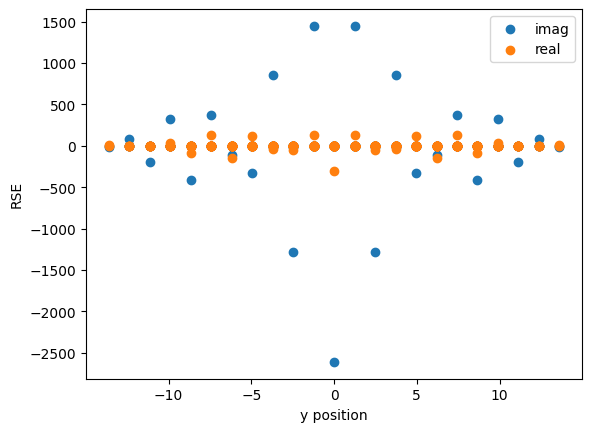

In [29]:
plt.scatter(HamNN_reorder.xyz[:,1]-HamNN_reorder.geometry.center()[1],SE_imag.diagonal(),label='imag')
plt.scatter(HamNN_reorder.xyz[:,1]-HamNN_reorder.geometry.center()[1],SE_real.diagonal(),label='real')
plt.xlabel('y position')
plt.ylabel('RSE')
plt.legend()